# Human-Synthetic Comparision SMS Spam Detection using CNN in Keras

Here I will build a Convolutional Neural Network (CNN) model to classify SMS messages as **spam** or **ham (not spam)** using TensorFlow/Keras.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load dataset
df = pd.read_csv("SMSSpamCollection", sep="\t", header=None, names=["label", "message"])
print(df.head())

# Encode labels: ham = 0, spam = 1
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df["message"], df["label_encoded"], test_size=0.2, random_state=42
)

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

maxlen = 100  # Max sequence length
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen)
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen)

vocab_size = len(tokenizer.word_index) + 1


  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [2]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

embedding_dim = 50  # Size of word vectors

# Input layer with fixed sequence length
inputs = Input(shape=(maxlen,))

# Embedding layer to convert word indices to dense vectors
embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen)(inputs)

# Convolutional layer: apply 128 filters of size 5
conv = Conv1D(filters=128, kernel_size=5, activation='relu')(embedding)

# Max pooling: pick the most important features (max value) from each filter
pool = GlobalMaxPooling1D()(conv)

# Dropout layer: randomly zero out 50% of neurons to prevent overfitting
drop = Dropout(0.5)(pool)

# Output layer: sigmoid for binary classification
output = Dense(1, activation='sigmoid')(drop)

# Create and compile the model
model = Model(inputs, output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Show model summary
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 50)        │       397,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 128)        │        32,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,957 (1.64 MB)

 Trainable params: 429,957 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Train the model for 5 epochs with 10% validation split
history = model.fit(X_train_pad, y_train, epochs=5, batch_size=32, validation_split=0.1)


Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8334 - loss: 0.4336 - val_accuracy: 0.9507 - val_loss: 0.1626
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9792 - loss: 0.0788 - val_accuracy: 0.9709 - val_loss: 0.0999
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9936 - loss: 0.0260 - val_accuracy: 0.9731 - val_loss: 0.1026
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9978 - loss: 0.0107 - val_accuracy: 0.9731 - val_loss: 0.1043
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9984 - loss: 0.0078 - val_accuracy: 0.9753 - val_loss: 0.1116


In [4]:
# Evaluate on the test set
loss, accuracy = model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {accuracy:.2f}")


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9900 - loss: 0.0445
Test Accuracy: 0.99


In [5]:
# Function to make predictions on new messages
def predict_message(msg):
    seq = tokenizer.texts_to_sequences([msg])         # Convert text to sequence
    pad = pad_sequences(seq, maxlen=maxlen)           # Pad the sequence
    pred = model.predict(pad)[0][0]                   # Get prediction probability
    return "Spam" if pred > 0.5 else "Ham"            # Threshold at 0.5

# Predictions on new messages
print(predict_message("Congratulations! You have won a free ticket. Call now."))  # Expected: Spam
print(predict_message("Hi, are we still on for lunch?"))                         # Expected: Ham


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Spam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Ham


## Synthetic Dataset

In [6]:
# Load synthetic dataset (no header, tab-separated)
df_syn = pd.read_csv("Merged_Cleaned_Synthetic_SMSSpamCollection.csv", sep="\t", header=0)
print(df_syn.head())

# Encode labels: ham = 0, spam = 1
le_syn = LabelEncoder()
df_syn["label_encoded"] = le_syn.fit_transform(df_syn["label"])

# Split synthetic data (80% train, 20% test)
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    df_syn["message"], df_syn["label_encoded"], test_size=0.2, random_state=42
)

# Tokenize and pad sequences
tokenizer_syn = Tokenizer(num_words=5000)
tokenizer_syn.fit_on_texts(X_train_syn)

X_train_seq_syn = tokenizer_syn.texts_to_sequences(X_train_syn)
X_test_seq_syn = tokenizer_syn.texts_to_sequences(X_test_syn)

maxlen_syn = 100  # Max sequence length
X_train_pad_syn = pad_sequences(X_train_seq_syn, maxlen=maxlen_syn)
X_test_pad_syn = pad_sequences(X_test_seq_syn, maxlen=maxlen_syn)

vocab_size_syn = len(tokenizer_syn.word_index) + 1

  label                                            message
0   ham  and watch a film about a guy named Bill. They'...
1   ham  and get some dinner, but I'm just not sure how...
2   ham  How about something like this one? Thank you! ...
3   ham                                          at 6 a.m.
4  spam  to play your favourite MMO in one of our exclu...


In [7]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

embedding_dim = 50  # Size of word vectors

# Input layer for synthetic dataset
inputs_syn = Input(shape=(maxlen_syn,))

# Embedding layer
embedding_syn = Embedding(
    input_dim=vocab_size_syn,
    output_dim=embedding_dim,
    input_length=maxlen_syn
)(inputs_syn)

# Convolution layer
conv_syn = Conv1D(filters=128, kernel_size=5, activation='relu')(embedding_syn)

# Max pooling
pool_syn = GlobalMaxPooling1D()(conv_syn)

# Dropout to reduce overfitting
drop_syn = Dropout(0.5)(pool_syn)

# Output layer for binary classification
output_syn = Dense(1, activation='sigmoid')(drop_syn)

# Build and compile model
model_syn = Model(inputs_syn, output_syn)
model_syn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Summary
model_syn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 100, 50)        │       208,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 96, 128)        │        32,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,607 (939.87 KB)

 Trainable params: 240,607 (939.87 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train the CNN model on the synthetic dataset
history_syn = model_syn.fit(
    X_train_pad_syn, y_train_syn,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)


Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6661 - loss: 0.6281 - val_accuracy: 0.8537 - val_loss: 0.3927
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9209 - loss: 0.2930 - val_accuracy: 0.9160 - val_loss: 0.2330
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9582 - loss: 0.1311 - val_accuracy: 0.9322 - val_loss: 0.2125
Epoch 4/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9698 - loss: 0.0852 - val_accuracy: 0.9322 - val_loss: 0.2275
Epoch 5/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9881 - loss: 0.0490 - val_accuracy: 0.9295 - val_loss: 0.2429


In [9]:
# Evaluate the synthetic model on the synthetic test set
loss_syn, accuracy_syn = model_syn.evaluate(X_test_pad_syn, y_test_syn)
print(f"Synthetic Test Accuracy: {accuracy_syn:.2f}")


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9447 - loss: 0.2383
Synthetic Test Accuracy: 0.95


In [10]:
# Function to make predictions using the synthetic model
def predict_message_syn(msg):
    seq = tokenizer_syn.texts_to_sequences([msg])      # Convert text to sequence using synthetic tokenizer
    pad = pad_sequences(seq, maxlen=maxlen_syn)        # Pad the sequence to synthetic maxlen
    pred = model_syn.predict(pad)[0][0]                # Get prediction probability from synthetic model
    return "Spam" if pred > 0.5 else "Ham"             # Threshold at 0.5

# Predictions on new messages using synthetic model
print(predict_message_syn("Congratulations! You have won a free ticket. Call now."))  # Expected: Spam
print(predict_message_syn("Hi, are we still on for lunch?"))                         # Expected: Ham


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Spam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Ham


In [11]:
# For original dataset
print("Original Dataset Label Counts:")
print(df['label'].value_counts())

# For synthetic dataset
print("\nSynthetic Dataset Label Counts:")
print(df_syn['label'].value_counts())


Original Dataset Label Counts:
label
ham     4825
spam     747
Name: count, dtype: int64

Synthetic Dataset Label Counts:
label
ham     3050
spam    1553
Name: count, dtype: int64


In [12]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

# Predict on original test data
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Original Dataset Test Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# For synthetic dataset
y_pred_prob_syn = model_syn.predict(X_test_pad_syn)
y_pred_syn = (y_pred_prob_syn > 0.5).astype(int)

print("\nSynthetic Dataset Test Metrics:")
print("Accuracy:", accuracy_score(y_test_syn, y_pred_syn))
print("Precision:", precision_score(y_test_syn, y_pred_syn))
print("Recall:", recall_score(y_test_syn, y_pred_syn))
print("F1 Score:", f1_score(y_test_syn, y_pred_syn))
print("\nClassification Report:\n", classification_report(y_test_syn, y_pred_syn, target_names=['Ham', 'Spam']))


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Original Dataset Test Metrics:
Accuracy: 0.9901345291479821
Precision: 0.9726027397260274
Recall: 0.9530201342281879
F1 Score: 0.9627118644067797

Classification Report:
               precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       0.97      0.95      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Synthetic Dataset Test Metrics:
Accuracy: 0.9467969598262758
Precision: 0.951048951048951
Recall: 0.8859934853420195
F1 Score: 0.9173693086003373

Classification Report:
               precision    recall  f1-score   support

         Ham       0.94      0.98      0.96       614
        Spam       0.95      0.89      0.92       307

    accuracy                           0.95       921
   macro avg       0.95      0.93 

In [15]:
# Tokenize and pad the original test set using the synthetic tokenizer and padding parameters
X_test_seq_on_syn = tokenizer_syn.texts_to_sequences(X_test)  # tokenize original test with synthetic tokenizer
X_test_pad_on_syn = pad_sequences(X_test_seq_on_syn, maxlen=maxlen_syn)  # pad with synthetic max_length

# Predict using the synthetic-trained model on original test data
y_pred_prob_syn_on_orig = model_syn.predict(X_test_pad_on_syn)
y_pred_syn_on_orig = (y_pred_prob_syn_on_orig > 0.5).astype(int)

print("\nSynthetic Model Tested on Original Dataset Test Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_syn_on_orig))
print("Precision:", precision_score(y_test, y_pred_syn_on_orig))
print("Recall:", recall_score(y_test, y_pred_syn_on_orig))
print("F1 Score:", f1_score(y_test, y_pred_syn_on_orig))
print("\nClassification Report:\n", classification_report(y_test, y_pred_syn_on_orig, target_names=['Ham', 'Spam']))


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Synthetic Model Tested on Original Dataset Test Metrics:
Accuracy: 0.9049327354260089
Precision: 0.6352201257861635
Recall: 0.6778523489932886
F1 Score: 0.6558441558441559

Classification Report:
               precision    recall  f1-score   support

         Ham       0.95      0.94      0.94       966
        Spam       0.64      0.68      0.66       149

    accuracy                           0.90      1115
   macro avg       0.79      0.81      0.80      1115
weighted avg       0.91      0.90      0.91      1115



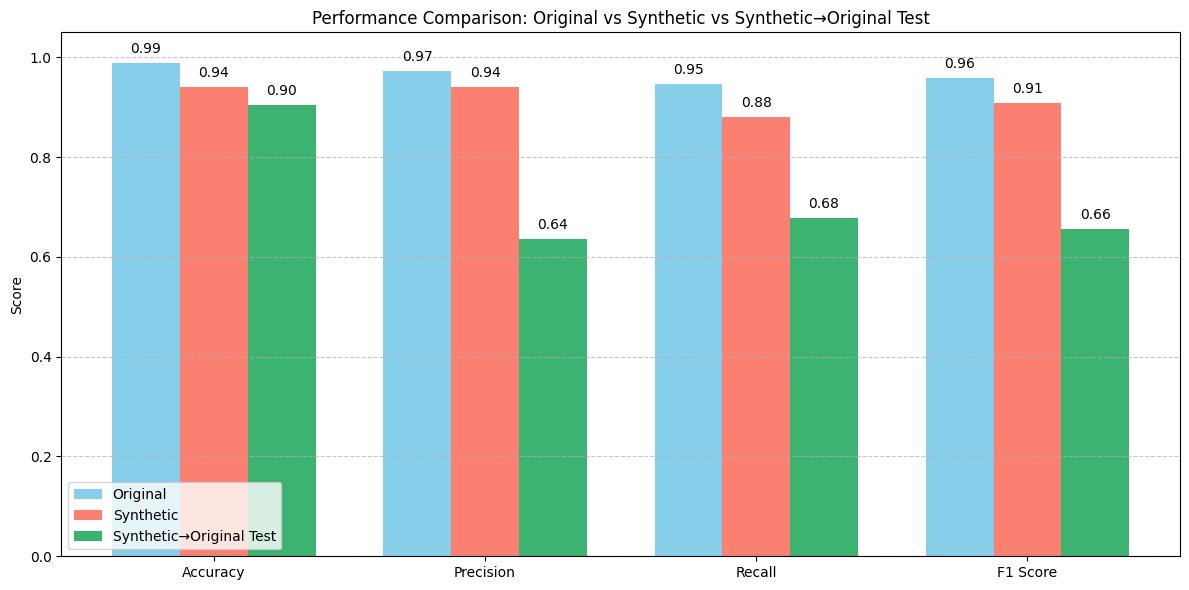

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics to plot
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

# Scores
original_scores = [0.9892, 0.9724, 0.9463, 0.9592]
synthetic_scores = [0.9414, 0.9408, 0.8795, 0.9091]
synthetic_on_original_scores = [0.9049, 0.6352, 0.6779, 0.6558]

x = np.arange(len(metrics))  # label locations
width = 0.25  # narrower bars to fit 3 groups

fig, ax = plt.subplots(figsize=(12, 6))

# Create the bars
bars1 = ax.bar(x - width, original_scores, width, label='Original', color='skyblue')
bars2 = ax.bar(x, synthetic_scores, width, label='Synthetic', color='salmon')
bars3 = ax.bar(x + width, synthetic_on_original_scores, width, label='Synthetic→Original Test', color='mediumseagreen')

# Add labels and formatting
ax.set_ylabel('Score')
ax.set_title('Performance Comparison: Original vs Synthetic vs Synthetic→Original Test')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.legend()

# Display value labels on all bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
